# Figure 2 of Pierard2024TheTile: Geometry of canonical ranking scores in ROC

In [1]:
from sorbetto.geometry import Line, PencilOfLines, Point
from sorbetto.ranking import RankingScore
from sorbetto.parameterization import ParameterizationDefault

import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Choose the values of the parameters
prior_pos = 0.2
a = 0.95
b = 0.7

# Choose the bounds for the plot. We want the plot to be with a 4/3 aspect ratio.
min_fpr, max_fpr = 0.5-1.6, 0.5+1.6
min_tpr, max_tpr = 0.5-1.2, 0.5+1.2
extent = [ min_fpr, max_fpr, min_tpr, max_tpr ]

# Precompute the axis-aligned bounding boxes in which we want to draw things.
extent_roc = [ 0.0, 1.0, 0.0, 1.0 ]
extent_bottom_left = [ min_fpr, 0.0, min_tpr, 0.0 ]
extent_top_right = [ 1.0, max_fpr, 1.0, max_tpr ]

# The three pencils of lines that are depicted in this notebook correspond to the sets of lines 
# for which some function (a ranking score, the parameter "a", and the parameter "b") take a constant
# value. In all three cases, the line obtained with lamba_1=1-bv and lambda_2=v is the one corresponding
# to the value v taken by the function.
lambdas = [ (1-v,v) for v in np.linspace(0,1,11) ]

In [3]:
# A utility function that draws the "background" elements common to all our plots.
def start_plotting (fig, ax) :

    # plot bottom-left area in which the score's vertex can be
    ax.fill ( [0, 0, min_fpr, min_fpr], [0, min_tpr, min_tpr, 0], color='lightgray')

    # plot top-right area in which the score's vertex can be
    ax.fill ( [1, 1, max_fpr, max_fpr], [1, max_tpr, max_tpr, 1], color='lightgray')
    
    # plot ROC's border
    ax.plot ( [0, 1, 1, 0, 0] , [ 0, 0, 1, 1, 0 ], '-', c='k' )
    ax.text ( 0.5, 1.05, 'ROC', horizontalalignment='center' )
    ax.arrow ( 0, 0, 1+0.1, 0, color='k', head_width=0.05 )
    ax.text ( 1+2*0.1, 0, '$FPR$', c='k' )
    ax.arrow ( 0, 0, 0, 1+0.1, color='k', head_width=0.05 )
    ax.text ( 0, 1+2*0.1, '$TPR$', c='k', rotation='vertical' )

# A utility function that setups properly the axes.
def stop_plotting (fig, ax) :
    ax.set_xticks ( [] )
    ax.set_yticks ( [] )
    ax.set_xlim ( (min_fpr, max_fpr) )
    ax.set_ylim ( (min_tpr, max_tpr) )
    ax.set_aspect ( 'equal' )

## Pencil of lines for the canonical ranking score, $R_{I_{a,b}}$

/Users/pierard/Documents/GitHub/sorbetto/examples/sorbetto/geometry/line_segment.py:65: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([p1.x, p2.x], [p1.y, p2.y], "-", **options_for_plot)


Text(0.5, 1.0, 'Pencil of lines for the canonical ranking score, $R_{I_{a,b}}$')

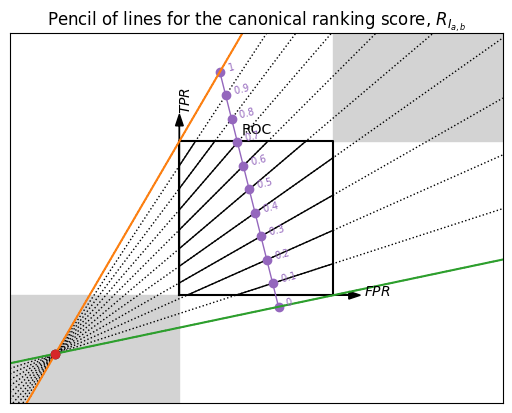

In [4]:
parameterization = ParameterizationDefault ()
score = parameterization.getCanonicalRankingScore ( a, b )
f = score.toROC ( prior_pos )

# The pencil of lines depicted in Figure 2a.
pencil_score = f.getPencil ()
# The red point depicted in Figures 2a, 2b, and 2c.
vertex_score = pencil_score.getVertex ()
# The green line depicted in Figures 2a and 2b.
line_score_val_0 = pencil_score.getLine ( 1.0, 0.0 )
# The orange line depicted in Figures 2a and 2c.
line_score_val_1 = pencil_score.getLine ( 0.0, 1.0 )

x, y = 0.5, 0.5
vmin, vmax = 0.0, 1.0
ticks = np.linspace ( vmin, vmax, 11 )
ruler_score = f.getRuler ( x, y, vmin, vmax, ticks )

def plot_pencil_canonical_ranking_score ( fig=None, ax=None, draw_ruler:bool=True ) :
    if fig is None or ax is None :
        fig, ax = plt.subplots ()
    start_plotting (fig, ax)
    pencil_score.draw ( fig, ax, extent, lambdas=lambdas, linestyle=':', color='k', linewidth=1 )
    pencil_score.draw ( fig, ax, extent_roc, lambdas=lambdas, linestyle='-', color='k', linewidth=1 )
    if draw_ruler:
        ruler_score.draw ( fig, ax, extent, lambdas=lambdas, color='tab:purple', linewidth=1 )
    line_score_val_0.draw ( fig, ax, extent, color='tab:green', linewidth=1.5 )
    line_score_val_1.draw ( fig, ax, extent, color='tab:orange', linewidth=1.5 )
    vertex_score.draw ( fig, ax, extent, color='tab:red' )
    stop_plotting (fig, ax)

plot_pencil_canonical_ranking_score ()
plt.title ( 'Pencil of lines for the canonical ranking score, $R_{I_{a,b}}$' )

## Pencil of lines for the first parameter, $a$

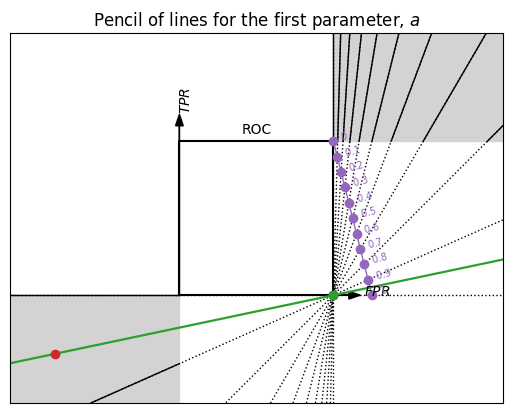

In [5]:
parameterization = ParameterizationDefault ()
f = parameterization.getParameter1ForValueZeroInROC ( prior_pos )

# The pencil of lines depicted in Figure 2b.
pencil_param_a = f.getPencil ()
# The green point depicted in Figure 2b.
vertex_param_a = pencil_param_a.getVertex ()
assert vertex_param_a == Point ( 1.0, 0.0 )
# The green line depicted in Figures 2a and 2b.
line_param_a = pencil_param_a.getLine ( 1.0-a, a )
assert line_param_a == line_score_val_0

x, y = 1.0, 1.0
vmin, vmax = 0.0, 1.0
ticks = np.linspace ( vmin, vmax, 11 )
ruler_param_a = f.getRuler ( x, y, vmin, vmax, ticks )

def plot_pencil_parameter_1 ( fig=None, ax=None, draw_ruler:bool=True ) :
    if fig is None or ax is None :
        fig, ax = plt.subplots ()
    start_plotting (fig, ax)
    pencil_param_a.draw ( fig, ax, extent, lambdas=lambdas, linestyle=':', color='k', linewidth=1 )
    pencil_param_a.draw ( fig, ax, extent_bottom_left, lambdas=lambdas, linestyle='-', color='k', linewidth=1 )
    pencil_param_a.draw ( fig, ax, extent_top_right, lambdas=lambdas, linestyle='-', color='k', linewidth=1 )
    if draw_ruler:
        ruler_param_a.draw ( fig, ax, extent, lambdas=lambdas, color='tab:purple', linewidth=1 )
    line_param_a.draw ( fig, ax, extent, color='tab:green', linewidth=1.6 )
    vertex_param_a.draw ( fig, ax, extent, color='tab:green' )
    vertex_score.draw ( fig, ax, extent, color='tab:red' )
    stop_plotting (fig, ax)
    return fig, ax

plot_pencil_parameter_1 ()
plt.title ( 'Pencil of lines for the first parameter, $a$' );

## Pencil of lines for the second parameter, $b$

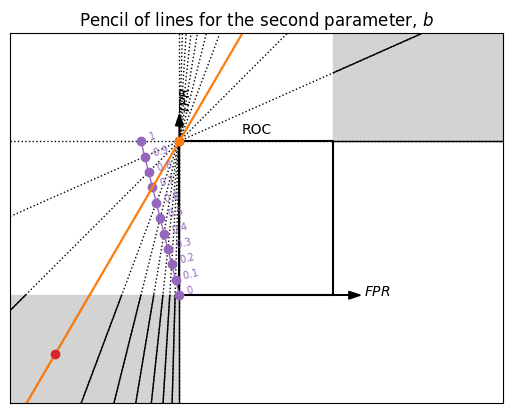

In [6]:
parameterization = ParameterizationDefault ()
f = parameterization.getParameter2ForValueOneInROC ( prior_pos )

# The pencil of lines depicted in Figure 2c.
pencil_param_b = f.getPencil ()
# The orange point depicted in Figure 2c.
vertex_param_b = pencil_param_b.getVertex ()
assert vertex_param_b == Point ( 0.0, 1.0 )
# The orange line depicted in Figures 2a and 2c.
line_param_b = pencil_param_b.getLine ( 1.0-b, b )
assert line_param_b == line_score_val_1

x, y = 0.0, 0.0
vmin, vmax = 0.0, 1.0
ticks = np.linspace ( vmin, vmax, 11 )
ruler_param_b = f.getRuler ( x, y, vmin, vmax, ticks )

def plot_pencil_parameter_2 ( fig=None, ax=None, draw_ruler:bool=True ) :
    if fig is None or ax is None :
        fig, ax = plt.subplots ()
    start_plotting (fig, ax)
    pencil_param_b.draw ( fig, ax, extent, lambdas=lambdas, linestyle=':', color='k', linewidth=1 )
    pencil_param_b.draw ( fig, ax, extent_bottom_left, lambdas=lambdas, linestyle='-', color='k', linewidth=1 )
    pencil_param_b.draw ( fig, ax, extent_top_right, lambdas=lambdas, linestyle='-', color='k', linewidth=1 )
    if draw_ruler:
        ruler_param_b.draw ( fig, ax, extent, lambdas=lambdas, color='tab:purple', linewidth=1 )
    line_param_b.draw ( fig, ax, extent, color='tab:orange', linewidth=1.6 )
    vertex_param_b.draw ( fig, ax, extent, color='tab:orange' )
    vertex_score.draw ( fig, ax, extent, color='tab:red' )
    stop_plotting (fig, ax)
    return fig, ax

plot_pencil_parameter_2 ()
plt.title ( 'Pencil of lines for the second parameter, $b$' );

## All together

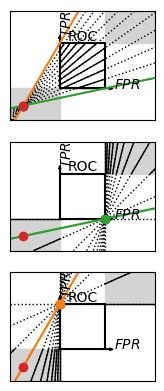

In [7]:
figure, axis = plt.subplots(3, 1)

draw_ruler = False

plot_pencil_canonical_ranking_score(figure, axis[0], draw_ruler)
plot_pencil_parameter_1(figure, axis[1], draw_ruler)
plot_pencil_parameter_2(figure, axis[2], draw_ruler);